In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def load_training_history(csv_path):
    """
    Load training history from CSV and make sure available numeric columns are converted.
    """
    df = pd.read_csv(csv_path)

    required_columns = ["epoch", "loss", "val_loss"]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # Convert every possible numeric column
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="ignore")

    df = df.sort_values("epoch").reset_index(drop=True)

    return df


def find_best_epoch(df):
    """
    Find the epoch with the lowest validation loss.
    """
    best_idx = df["val_loss"].idxmin()

    return {
        "best_idx": best_idx,
        "best_epoch": df.loc[best_idx, "epoch"],
        "best_train_loss": df.loc[best_idx, "loss"],
        "best_val_loss": df.loc[best_idx, "val_loss"],
    }


def estimate_underfitting_region(df, best_val_loss, underfit_ratio=0.70):
    """
    Estimate the initial underfitting region using validation-loss improvement.
    """
    initial_val_loss = df["val_loss"].iloc[0]

    improvement_target = initial_val_loss - underfit_ratio * (
        initial_val_loss - best_val_loss
    )

    underfit_candidates = df[df["val_loss"] > improvement_target]

    if len(underfit_candidates) > 0:
        underfit_end_epoch = underfit_candidates["epoch"].iloc[-1]
    else:
        underfit_end_epoch = df["epoch"].iloc[0]

    return underfit_end_epoch


def estimate_overfitting_region(best_epoch):
    """
    Simple rule: overfitting starts after the best validation epoch.
    """
    return best_epoch


def plot_training_history(
    df,
    best_info,
    underfit_end_epoch,
    overfit_start_epoch,
    save_path=None,
    show=True,
):
    """
    Plot training loss, validation loss, best epoch,
    likely underfitting region, and likely overfitting region.
    """
    best_epoch = best_info["best_epoch"]
    best_val_loss = best_info["best_val_loss"]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        df["epoch"],
        df["loss"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Training Loss",
    )

    ax.plot(
        df["epoch"],
        df["val_loss"],
        linewidth=2,
        marker="s",
        markersize=3,
        label="Validation Loss",
    )

    ax.axvspan(
        df["epoch"].iloc[0],
        underfit_end_epoch,
        alpha=0.15,
        label="Likely underfitting region",
    )

    ax.axvspan(
        overfit_start_epoch,
        df["epoch"].iloc[-1],
        alpha=0.12,
        label="Likely overfitting region",
    )

    ax.scatter(
        best_epoch,
        best_val_loss,
        s=120,
        zorder=5,
        label=f"Best epoch: {best_epoch}",
    )

    ax.axvline(
        best_epoch,
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )

    ax.annotate(
        f"Best epoch = {best_epoch}\nval_loss = {best_val_loss:.4f}",
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + 10, best_val_loss + 0.25),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
        fontsize=10,
    )

    y_text = max(df["loss"].max(), df["val_loss"].max()) * 0.92

    ax.text(
        df["epoch"].iloc[0],
        y_text,
        "Underfitting:\nboth losses are high",
        fontsize=10,
        verticalalignment="top",
    )

    ax.text(
        overfit_start_epoch + 5,
        y_text,
        "Overfitting:\ntraining loss keeps falling\nvalidation loss stops improving",
        fontsize=10,
        verticalalignment="top",
    )

    ax.set_title("Training and Validation Loss with Best Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    ax.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    ax.grid(True, which="major", linestyle="--", alpha=0.4)

    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax


def plot_optional_student_losses(
    df,
    student_prefix="train_s1",
    title="Student 1 Training Losses",
    save_path=None,
    show=True,
):
    """
    Plot optional student loss components only if they exist in the DataFrame.

    For student_prefix='train_s1', it checks:
        train_s1_loss
        train_s1_ce
        train_s1_kd
        train_s1_feature
    """

    loss_columns = {
        f"{student_prefix}_loss": "Total loss",
        f"{student_prefix}_ce": "CE loss",
        f"{student_prefix}_kd": "KD loss",
        f"{student_prefix}_feature": "Feature loss",
    }

    available_columns = {
        col: label
        for col, label in loss_columns.items()
        if col in df.columns
    }

    if len(available_columns) == 0:
        print(f"No {student_prefix} loss columns found. Skipping student loss plot.")
        return None, None

    fig, ax = plt.subplots(figsize=(10, 6))

    for col, label in available_columns.items():
        ax.plot(
            df["epoch"],
            df[col],
            marker="o",
            linewidth=2,
            markersize=3,
            label=label,
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax


def print_training_summary(
    best_info,
    underfit_end_epoch,
    overfit_start_epoch,
    first_epoch,
):
    """
    Print summary of the training behavior.
    """
    print("=" * 60)
    print("Training Summary")
    print("=" * 60)
    print(f"Best epoch: {best_info['best_epoch']}")
    print(f"Training loss at best epoch: {best_info['best_train_loss']:.6f}")
    print(f"Validation loss at best epoch: {best_info['best_val_loss']:.6f}")
    print(f"Likely underfitting region: epoch {first_epoch} to {underfit_end_epoch}")
    print(f"Likely overfitting region: after epoch {overfit_start_epoch}")
    print("=" * 60)


def analyze_and_plot_training_history(
    csv_path,
    save_main_path=None,
    save_student_path=None,
    underfit_ratio=0.70,
    plot_student_losses=True,
    show=True,
):
    """
    Complete reusable pipeline:
        1. Load CSV
        2. Find best epoch
        3. Estimate underfitting
        4. Estimate overfitting
        5. Plot main loss curve
        6. Optionally plot student loss components if columns exist
        7. Print summary

    save_main_path:
        None -> do not save main plot
        "file.png" -> save main plot

    save_student_path:
        None -> do not save student-loss plot
        "file.png" -> save student-loss plot
    """

    df = load_training_history(csv_path)

    best_info = find_best_epoch(df)

    underfit_end_epoch = estimate_underfitting_region(
        df=df,
        best_val_loss=best_info["best_val_loss"],
        underfit_ratio=underfit_ratio,
    )

    overfit_start_epoch = estimate_overfitting_region(
        best_epoch=best_info["best_epoch"]
    )

    main_fig, main_ax = plot_training_history(
        df=df,
        best_info=best_info,
        underfit_end_epoch=underfit_end_epoch,
        overfit_start_epoch=overfit_start_epoch,
        save_path=save_main_path,
        show=show,
    )

    student_fig, student_ax = None, None

    if plot_student_losses:
        student_fig, student_ax = plot_optional_student_losses(
            df=df,
            student_prefix="train_s1",
            title="Student 1 Training Losses",
            save_path=save_student_path,
            show=show,
        )

    print_training_summary(
        best_info=best_info,
        underfit_end_epoch=underfit_end_epoch,
        overfit_start_epoch=overfit_start_epoch,
        first_epoch=df["epoch"].iloc[0],
    )

    return {
        "df": df,
        "best_info": best_info,
        "underfit_end_epoch": underfit_end_epoch,
        "overfit_start_epoch": overfit_start_epoch,
        "main_fig": main_fig,
        "main_ax": main_ax,
        "student_fig": student_fig,
        "student_ax": student_ax,
    }

# if __name__ == "__main__":
#     csv_path = "results/results_Rayleigh_2026-08-09.csv"

#     results = analyze_and_plot_training_history(
#         csv_path=csv_path,
#         save_main_path="training_validation_loss_with_best_epoch.png",
#         save_student_path="student_1_training_losses.png",
#         underfit_ratio=0.70,
#         plot_student_losses=True,
#     )

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def load_training_history(csv_path):
    """
    Load training history from CSV and safely convert numeric columns.

    Required columns:
        epoch, loss, val_loss

    Optional columns:
        train_s1_loss, train_s1_ce, train_s1_kd, train_s1_feature
    """
    df = pd.read_csv(csv_path)

    required_columns = ["epoch", "loss", "val_loss"]

    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    numeric_columns = [
        "epoch",
        "loss",
        "val_loss",
        "train_s1_loss",
        "train_s1_ce",
        "train_s1_kd",
        "train_s1_feature",
    ]

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Remove rows where the required numeric values are invalid
    df = df.dropna(subset=["epoch", "loss", "val_loss"])

    df = df.sort_values("epoch").reset_index(drop=True)

    return df


def find_best_epoch(df):
    """
    Find the epoch with the lowest validation loss.
    """
    best_idx = df["val_loss"].idxmin()

    best_info = {
        "best_idx": best_idx,
        "best_epoch": df.loc[best_idx, "epoch"],
        "best_train_loss": df.loc[best_idx, "loss"],
        "best_val_loss": df.loc[best_idx, "val_loss"],
    }

    return best_info


def estimate_underfitting_region(df, best_val_loss, underfit_ratio=0.70):
    """
    Estimate the initial underfitting region.

    underfit_ratio:
        0.50 -> shorter underfitting region
        0.70 -> balanced estimate
        0.90 -> longer underfitting region

    This is a heuristic:
    underfitting is estimated as the early phase where validation loss
    is still far from its best value.
    """
    initial_val_loss = df["val_loss"].iloc[0]

    improvement_target = initial_val_loss - underfit_ratio * (
        initial_val_loss - best_val_loss
    )

    underfit_candidates = df[df["val_loss"] > improvement_target]

    if len(underfit_candidates) > 0:
        underfit_end_epoch = underfit_candidates["epoch"].iloc[-1]
    else:
        underfit_end_epoch = df["epoch"].iloc[0]

    return underfit_end_epoch


def estimate_overfitting_region(best_epoch):
    """
    Estimate overfitting start.

    Simple rule:
    overfitting starts after the epoch with the lowest validation loss.
    """
    return best_epoch


def plot_training_history(
    df,
    best_info,
    underfit_end_epoch,
    overfit_start_epoch,
    save_path=None,
    show=True,
):
    """
    Plot training loss, validation loss, best epoch,
    likely underfitting region, and likely overfitting region.
    """
    best_epoch = best_info["best_epoch"]
    best_val_loss = best_info["best_val_loss"]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        df["epoch"],
        df["loss"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Training Loss",
    )

    ax.plot(
        df["epoch"],
        df["val_loss"],
        linewidth=2,
        marker="s",
        markersize=3,
        label="Validation Loss",
    )

    # Highlight likely underfitting region
    ax.axvspan(
        df["epoch"].iloc[0],
        underfit_end_epoch,
        alpha=0.15,
        label="Likely underfitting region",
    )

    # Highlight likely overfitting region
    ax.axvspan(
        overfit_start_epoch,
        df["epoch"].iloc[-1],
        alpha=0.12,
        label="Likely overfitting region",
    )

    # Mark best epoch
    ax.scatter(
        best_epoch,
        best_val_loss,
        s=120,
        zorder=5,
        label=f"Best epoch: {best_epoch}",
    )

    ax.axvline(
        best_epoch,
        linestyle="--",
        linewidth=2,
        alpha=0.7,
    )

    ax.annotate(
        f"Best epoch = {best_epoch}\nval_loss = {best_val_loss:.4f}",
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + 10, best_val_loss + 0.25),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
        fontsize=10,
    )

    # Text positions
    y_text = max(df["loss"].max(), df["val_loss"].max()) * 0.92

    ax.text(
        df["epoch"].iloc[0],
        y_text,
        "Underfitting:\nboth losses are high",
        fontsize=10,
        verticalalignment="top",
    )

    ax.text(
        overfit_start_epoch + 5,
        y_text,
        "Overfitting:\ntraining loss keeps falling\nvalidation loss stops improving",
        fontsize=10,
        verticalalignment="top",
    )

    ax.set_title("Training and Validation Loss with Best Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    ax.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    ax.grid(True, which="major", linestyle="--", alpha=0.4)

    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax


def plot_optional_student_losses(
    df,
    student_prefix="train_s1",
    title="Student 1 Training Losses",
    save_path=None,
    show=True,
):
    """
    Plot optional student loss components only if they exist in the DataFrame.

    For student_prefix='train_s1', it checks:
        train_s1_loss
        train_s1_ce
        train_s1_kd
        train_s1_feature
    """
    loss_columns = {
        f"{student_prefix}_loss": "Total loss",
        f"{student_prefix}_ce": "CE loss",
        f"{student_prefix}_kd": "KD loss",
        f"{student_prefix}_feature": "Feature loss",
    }

    available_columns = {
        col: label
        for col, label in loss_columns.items()
        if col in df.columns and df[col].notna().any()
    }

    if len(available_columns) == 0:
        print(f"No valid {student_prefix} loss columns found. Skipping student loss plot.")
        return None, None

    fig, ax = plt.subplots(figsize=(10, 6))

    for col, label in available_columns.items():
        ax.plot(
            df["epoch"],
            df[col],
            marker="o",
            linewidth=2,
            markersize=3,
            label=label,
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    ax.legend()
    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax


def print_training_summary(
    best_info,
    underfit_end_epoch,
    overfit_start_epoch,
    first_epoch,
):
    """
    Print summary of the training behavior.
    """
    print("=" * 60)
    print("Training Summary")
    print("=" * 60)
    print(f"Best epoch: {best_info['best_epoch']}")
    print(f"Training loss at best epoch: {best_info['best_train_loss']:.6f}")
    print(f"Validation loss at best epoch: {best_info['best_val_loss']:.6f}")
    print(f"Likely underfitting region: epoch {first_epoch} to {underfit_end_epoch}")
    print(f"Likely overfitting region: after epoch {overfit_start_epoch}")
    print("=" * 60)


def analyze_and_plot_training_history(
    csv_path,
    save_main_path=None,
    save_student_path=None,
    underfit_ratio=0.70,
    plot_student_losses=True,
    show=True,
):
    """
    Complete reusable pipeline:
        1. Load CSV
        2. Find best epoch
        3. Estimate underfitting
        4. Estimate overfitting
        5. Plot main loss curve
        6. Optionally plot student loss components if columns exist
        7. Print summary

    save_main_path:
        None -> do not save main plot
        "file.png" -> save main plot

    save_student_path:
        None -> do not save student-loss plot
        "file.png" -> save student-loss plot
    """
    df = load_training_history(csv_path)

    best_info = find_best_epoch(df)

    underfit_end_epoch = estimate_underfitting_region(
        df=df,
        best_val_loss=best_info["best_val_loss"],
        underfit_ratio=underfit_ratio,
    )

    overfit_start_epoch = estimate_overfitting_region(
        best_epoch=best_info["best_epoch"]
    )

    main_fig, main_ax = plot_training_history(
        df=df,
        best_info=best_info,
        underfit_end_epoch=underfit_end_epoch,
        overfit_start_epoch=overfit_start_epoch,
        save_path=save_main_path,
        show=show,
    )

    student_fig, student_ax = None, None

    if plot_student_losses:
        student_fig, student_ax = plot_optional_student_losses(
            df=df,
            student_prefix="train_s1",
            title="Student 1 Training Losses",
            save_path=save_student_path,
            show=show,
        )

    print_training_summary(
        best_info=best_info,
        underfit_end_epoch=underfit_end_epoch,
        overfit_start_epoch=overfit_start_epoch,
        first_epoch=df["epoch"].iloc[0],
    )

    return {
        "df": df,
        "best_info": best_info,
        "underfit_end_epoch": underfit_end_epoch,
        "overfit_start_epoch": overfit_start_epoch,
        "main_fig": main_fig,
        "main_ax": main_ax,
        "student_fig": student_fig,
        "student_ax": student_ax,
    }

## Main train

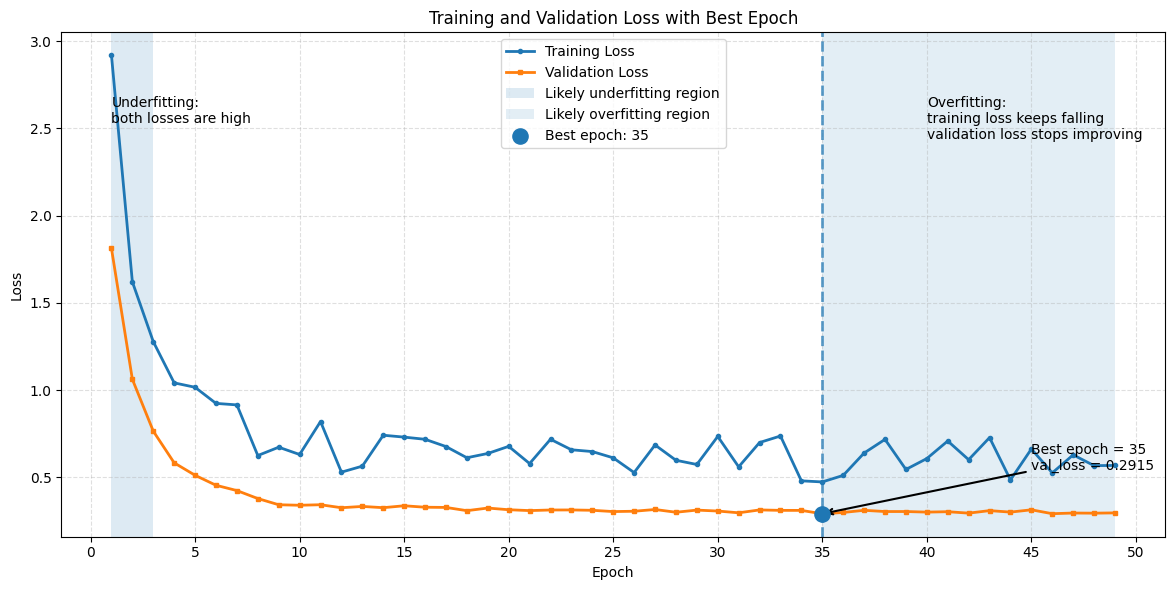

No valid train_s1 loss columns found. Skipping student loss plot.
Training Summary
Best epoch: 35
Training loss at best epoch: 0.474109
Validation loss at best epoch: 0.291506
Likely underfitting region: epoch 1 to 3
Likely overfitting region: after epoch 35


In [4]:
csv_path = "results/results_Rayleigh_2026-08-09.csv"

results = analyze_and_plot_training_history(
    csv_path=csv_path,
    save_main_path=None,
    save_student_path=None,
    underfit_ratio=0.70,
    plot_student_losses=True,
)

## Multi students

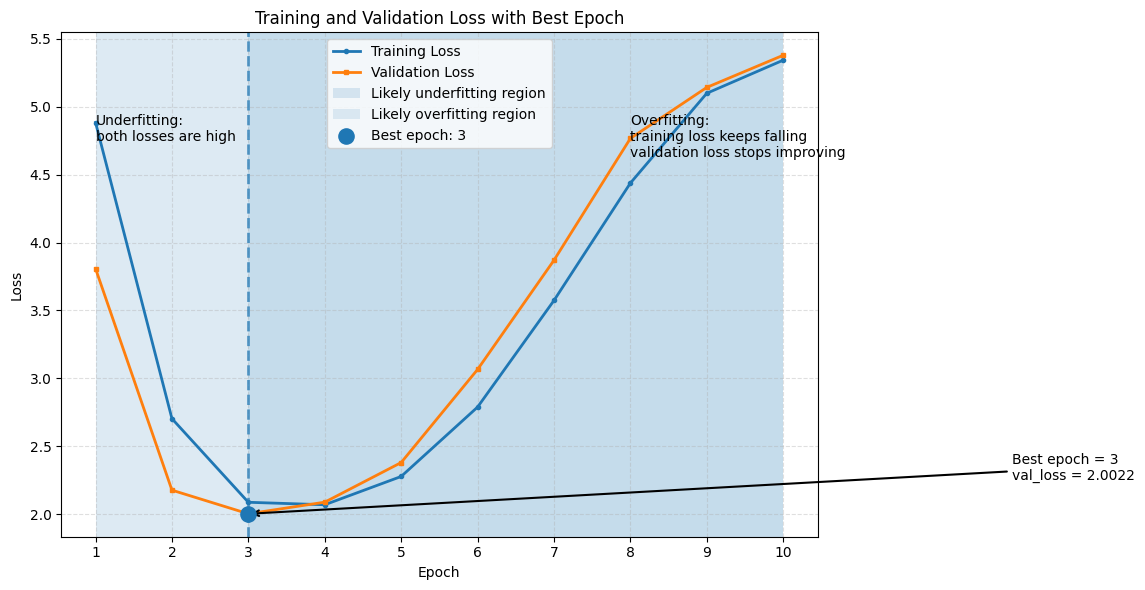

No valid train_s1 loss columns found. Skipping student loss plot.
Training Summary
Best epoch: 3
Training loss at best epoch: 2.087043
Validation loss at best epoch: 2.002243
Likely underfitting region: epoch 1 to 10
Likely overfitting region: after epoch 3


In [5]:
csv_path = "results/results_2026-08-10.csv"

results = analyze_and_plot_training_history(
    csv_path=csv_path,
    save_main_path=None,
    save_student_path=None,
    underfit_ratio=0.70,
    plot_student_losses=True,
)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


csv_path = "results/train_multi_students_results.csv"

df = pd.read_csv(csv_path)

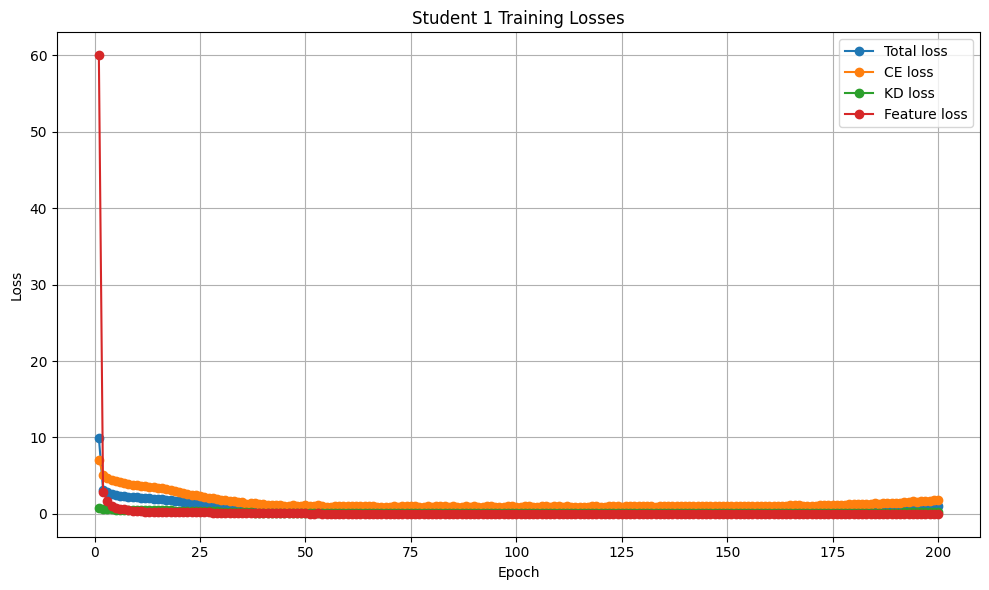

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["train_s1_loss"],
    marker="o",
    label="Total loss"
)

plt.plot(
    df["epoch"],
    df["train_s1_ce"],
    marker="o",
    label="CE loss"
)

plt.plot(
    df["epoch"],
    df["train_s1_kd"],
    marker="o",
    label="KD loss"
)

plt.plot(
    df["epoch"],
    df["train_s1_feature"],
    marker="o",
    label="Feature loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student 1 Training Losses")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

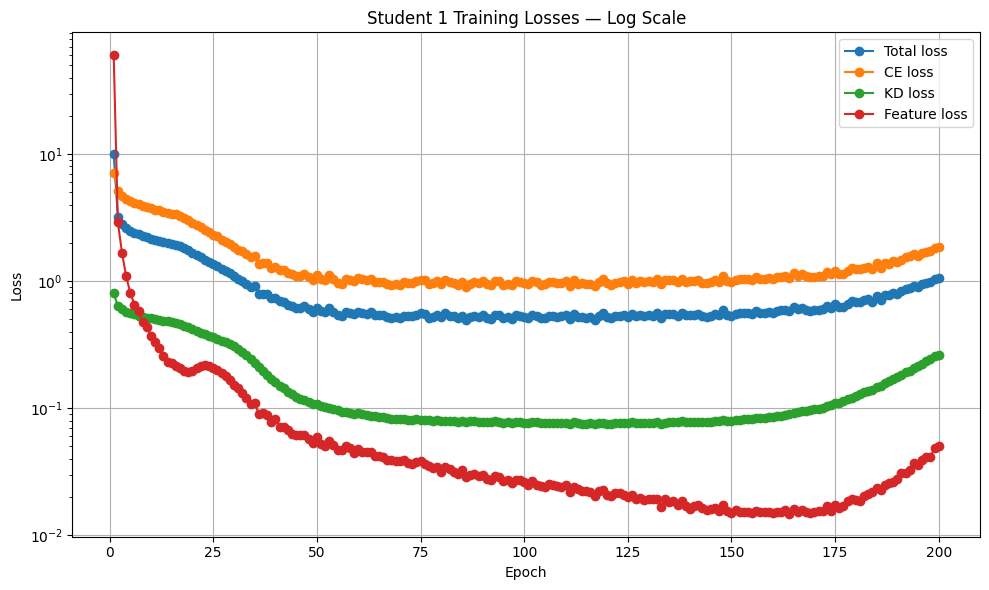

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(df["epoch"], df["train_s1_loss"], marker="o", label="Total loss")
plt.plot(df["epoch"], df["train_s1_ce"], marker="o", label="CE loss")
plt.plot(df["epoch"], df["train_s1_kd"], marker="o", label="KD loss")
plt.plot(df["epoch"], df["train_s1_feature"], marker="o", label="Feature loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student 1 Training Losses — Log Scale")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

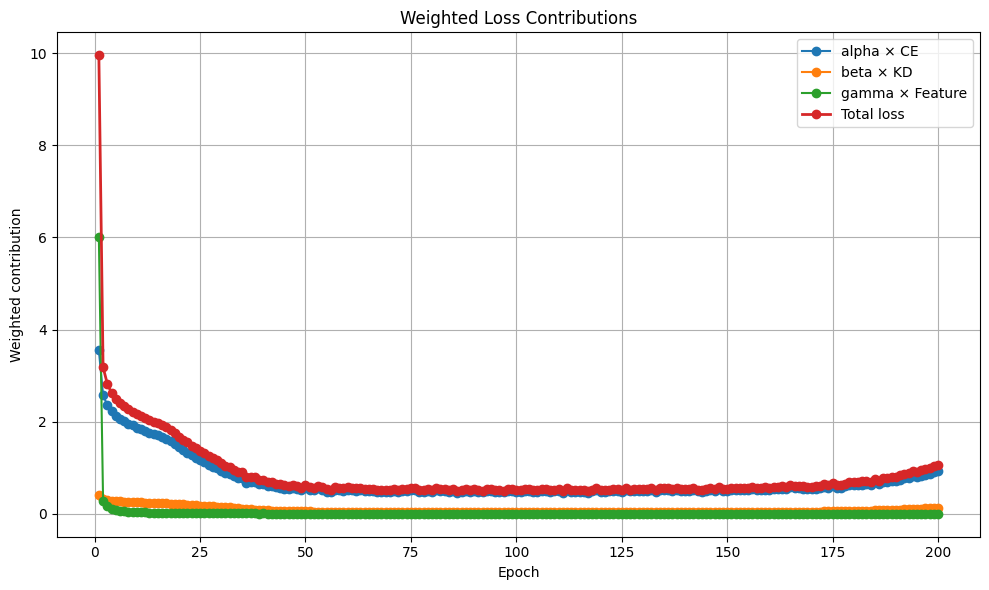

In [9]:
df["weighted_ce"] = df["alpha"] * df["train_s1_ce"]
df["weighted_kd"] = df["beta"] * df["train_s1_kd"]
df["weighted_feature"] = df["gamma"] * df["train_s1_feature"]

plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["weighted_ce"],
    marker="o",
    label="alpha × CE"
)

plt.plot(
    df["epoch"],
    df["weighted_kd"],
    marker="o",
    label="beta × KD"
)

plt.plot(
    df["epoch"],
    df["weighted_feature"],
    marker="o",
    label="gamma × Feature"
)

plt.plot(
    df["epoch"],
    df["train_s1_loss"],
    marker="o",
    linewidth=2,
    label="Total loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted contribution")
plt.title("Weighted Loss Contributions")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [10]:
calculated_total = (
    df["alpha"] * df["train_s1_ce"]
    + df["beta"] * df["train_s1_kd"]
    + df["gamma"] * df["train_s1_feature"]
)

print(
    pd.DataFrame({
        "epoch": df["epoch"],
        "saved_total": df["train_s1_loss"],
        "calculated_total": calculated_total,
    })
)

     epoch  saved_total  calculated_total
0        1     9.955450          9.955450
1        2     3.183115          3.183115
2        3     2.826113          2.826113
3        4     2.624113          2.624113
4        5     2.493360          2.493360
..     ...          ...               ...
195    196     0.945475          0.945475
196    197     0.969514          0.969514
197    198     0.988530          0.988530
198    199     1.042215          1.042215
199    200     1.058290          1.058290

[200 rows x 3 columns]


## LoRA

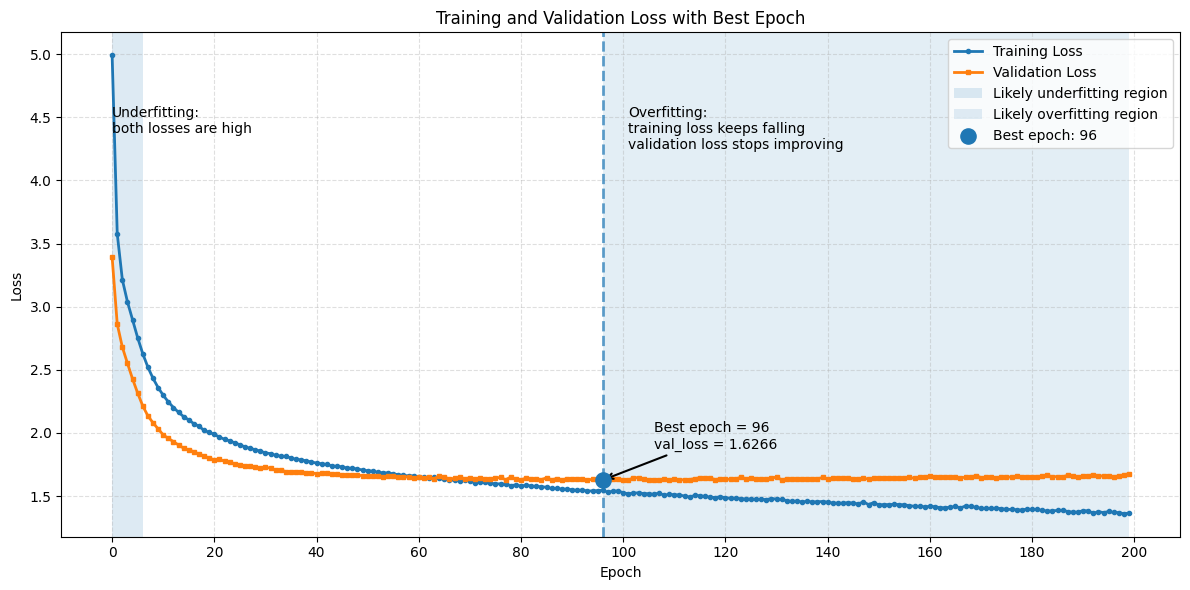

No valid train_s1 loss columns found. Skipping student loss plot.
Training Summary
Best epoch: 96
Training loss at best epoch: 1.545442
Validation loss at best epoch: 1.626564
Likely underfitting region: epoch 0 to 6
Likely overfitting region: after epoch 96


In [11]:
csv_path = "results/lora/results.csv"

results = analyze_and_plot_training_history(
    csv_path=csv_path,
    save_main_path=None,
    save_student_path=None,
    underfit_ratio=0.70,
    plot_student_losses=True,
)